# Punto 2 – CNN sobre Fashion-MNIST: desde cero, VGG16 y MobileNetV2

**Taller 1 – Aprendizaje Profundo** · Maestría en Inteligencia Artificial, Pontificia Universidad Javeriana

Las tres aproximaciones viven en un solo notebook a propósito: comparten partición, semilla, lotes, callbacks y métricas en una misma corrida, que es lo
que pide la rúbrica cuando habla de *comparación justa bajo condiciones documentadas*.

Orden del notebook:

1. **Datos y diseño experimental** (sección 1): carga, revisión de integridad, partición estratificada
   54 000 / 6 000 / 10 000 y pipeline `tf.data` común a las tres familias.
2. **Arquitecturas** (sección 2): CNN propia, VGG16 y MobileNetV2, las tres recibiendo la imagen
   original de 28×28×1. El redimensionamiento a 96×96, la conversión a RGB y el preprocesamiento de
   ImageNet ocurren *dentro* de cada modelo, así que no hay dos formatos de datos conviviendo.
3. **Búsqueda de hiperparámetros** (sección 3): presupuesto común, se varían capacidad, dropout,
   aumentación y learning rate.
4. **Entrenamiento final y fine-tuning** (sección 4) y **evaluación sobre test** (sección 5), que se
   toca una sola vez.
5. **Análisis de errores e incertidumbre** (sección 6) y guía de redacción (sección 7).

Requiere **GPU** (en Colab: *Entorno de ejecución > Cambiar tipo de entorno > T4*). El costo se
controla con la constante `PRESUPUESTO` de la primera celda de código, que queda registrada en
`results/punto2/entorno.json` para poder citarla en el informe:

| `PRESUPUESTO` | Búsqueda | Entrenamiento final | Duración en T4 |
|---|---|---|---|
| `"completo"` | las 54 000 imágenes, 12 épocas | 30 épocas + 15 de fine-tuning | ~2 h |
| `"acotado"` | 15 000 estratificadas, 8 épocas | 20 épocas + 8 de fine-tuning | ~1 h |
| `"depuracion"` | 12 000, 4 épocas | 8 épocas + 3 | ~10 min |

Buscar hiperparámetros sobre una submuestra y entrenar el modelo final con todo es práctica normal y
está declarado en el notebook; `"depuracion"` en cambio solo sirve para comprobar que todo corre, y
sus números **no** van al informe. VGG16 se lleva la mayor parte del tiempo en cualquiera de los tres.

Los resultados se guardan en `results/punto2/` a medida que avanzan, de modo que una desconexión a
mitad de camino no obliga a empezar de cero.


## 0. Preparación del entorno

In [1]:
import gc
import json
import os
import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             log_loss, precision_recall_fscore_support)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

SEED = 42
IMG_SIZE = 96                # tamaño al que se lleva la imagen para las redes de ImageNet
NUM_CLASSES = 10

# Presupuesto de cómputo. Se declara acá arriba porque cambia los números del informe, y queda
# guardado en entorno.json. "acotado" busca hiperparámetros sobre una submuestra estratificada y
# entrena el modelo final con las 54 000: práctica normal cuando la GPU es prestada.
PRESUPUESTO = "completo"     # "completo" | "acotado" | "depuracion"

PRESUPUESTOS = {
    "completo":   {"n_busqueda": None,  "epochs_search": 12, "epochs_final": 30, "epochs_ft": 15, "bootstrap": 1000},
    "acotado":    {"n_busqueda": 15000, "epochs_search": 8,  "epochs_final": 20, "epochs_ft": 8,  "bootstrap": 1000},
    "depuracion": {"n_busqueda": 12000, "epochs_search": 4,  "epochs_final": 8,  "epochs_ft": 3,  "bootstrap": 300},
}
_P = PRESUPUESTOS[PRESUPUESTO]
N_BUSQUEDA = _P["n_busqueda"]
EPOCHS_SEARCH = _P["epochs_search"]
EPOCHS_FINAL = _P["epochs_final"]
EPOCHS_FT = _P["epochs_ft"]
N_BOOTSTRAP = _P["bootstrap"]

HAY_GPU = bool(tf.config.list_physical_devices("GPU"))
BATCH_SIZE = 128 if HAY_GPU else 64
AUTOTUNE = tf.data.AUTOTUNE

# La T4 tiene tensor cores: con precisión mixta las convoluciones corren en float16 mientras los
# pesos, la pérdida y la salida siguen en float32. Es casi el doble de rápido en VGG16 y no cambia
# el diseño experimental. Si algo se ve raro, poner False y volver a correr.
USAR_MIXED_PRECISION = HAY_GPU
if USAR_MIXED_PRECISION:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")


def seed_all(s=SEED):
    """Se llama antes de construir cada modelo para que todas las corridas arranquen igual."""
    os.environ["PYTHONHASHSEED"] = str(s)
    random.seed(s)
    np.random.seed(s)
    tf.random.set_seed(s)


seed_all()
print("TensorFlow:", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))
print(f"PRESUPUESTO: {PRESUPUESTO} | búsqueda: {N_BUSQUEDA or 54000} imágenes x {EPOCHS_SEARCH} épocas"
      f" | final: {EPOCHS_FINAL} épocas + {EPOCHS_FT} de fine-tuning")
print("política numérica:", tf.keras.mixed_precision.global_policy().name)
if PRESUPUESTO == "depuracion":
    print("OJO: presupuesto de depuración. Estos números NO sirven para el informe.")
if not HAY_GPU:
    print("AVISO: sin GPU esto tarda horas. Entorno de ejecución > Cambiar tipo de entorno > T4.")


TensorFlow: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PRESUPUESTO: completo | búsqueda: 54000 imágenes x 12 épocas | final: 30 épocas + 15 de fine-tuning
política numérica: mixed_float16


In [2]:
# En Colab clonamos el repo para dejar los resultados en results/punto2.
REPO_URL = "https://github.com/DANIEL-VELASCO/taller1-deep-learning.git"
EN_COLAB = "google.colab" in sys.modules
print("Colab:", EN_COLAB)

if EN_COLAB:
    if not Path("/content/taller1-deep-learning").exists():
        !git clone -q {REPO_URL} /content/taller1-deep-learning
    RAIZ = Path("/content/taller1-deep-learning")
else:
    RAIZ = Path.cwd().resolve().parents[1]     # el notebook vive en code/punto2_cnn_fashion_mnist/

RUTA_RES = RAIZ / "results" / "punto2"
RUTA_RES.mkdir(parents=True, exist_ok=True)

# Los checkpoints y los modelos pesados se quedan FUERA del repo: un VGG16 guardado son unos
# 56 MB y GitHub avisa a partir de 50 MB. Al repo van las tablas, las figuras y la CNN pequeña.
RUTA_TMP = Path("/content/checkpoints") if EN_COLAB else Path("checkpoints_tmp")
RUTA_TMP.mkdir(parents=True, exist_ok=True)

print("resultados  ->", RUTA_RES)
print("temporales  ->", RUTA_TMP)


Colab: True
resultados  -> /content/taller1-deep-learning/results/punto2
temporales  -> /content/checkpoints


## 1. Datos y diseño experimental

Fashion-MNIST contiene 60 000 imágenes de desarrollo y 10 000 de test, de 28×28 píxeles en escala de grises y 10 clases. Se separa el desarrollo en 54 000 entrenamiento y 6 000 validación de forma estratificada. El test no participa en la búsqueda. Todas las familias usan la misma partición, semilla, criterio de parada y métricas. Las redes ImageNet requieren conversión a RGB y redimensionamiento.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
desarrollo: (60000, 28, 28) uint8 | test: (10000, 28, 28) uint8
rango de píxeles: 0 - 255
imágenes repetidas dentro de desarrollo: 0
imágenes de test que también están en desarrollo: 0
(54000, 28, 28) (6000, 28, 28) (10000, 28, 28)
train [5400 5400 5400 5400 5400 5400 5400 5400 5400 5400]
val [600 600 600 600 600 600 600 600 600 600]
test [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


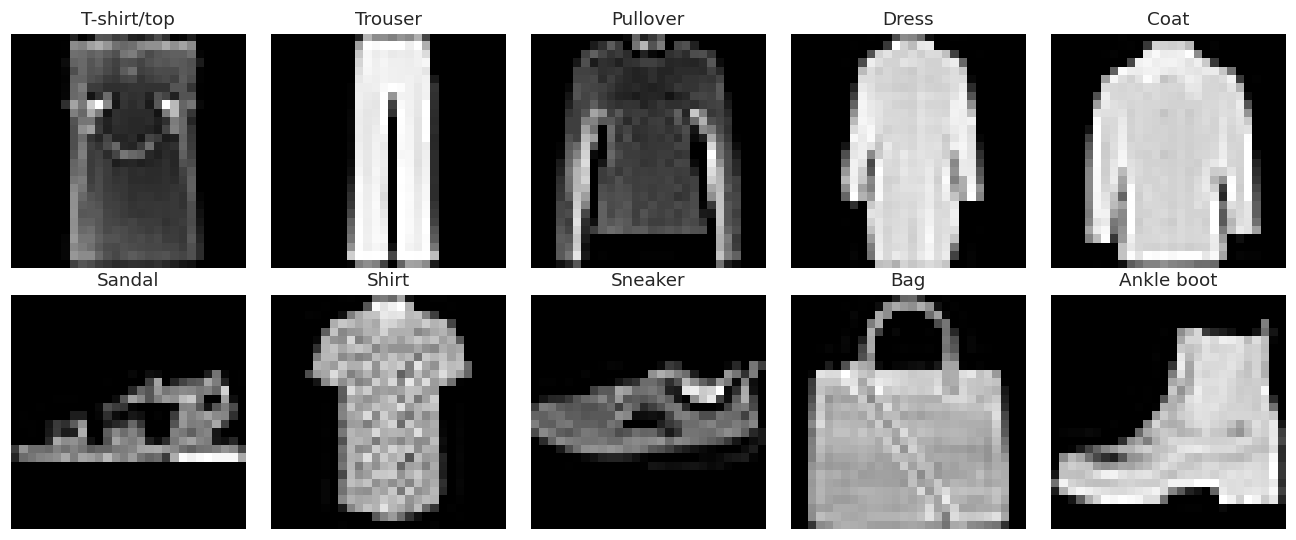

In [3]:
(x_dev, y_dev), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Revisión de integridad antes de partir nada.
print("desarrollo:", x_dev.shape, x_dev.dtype, "| test:", x_test.shape, x_test.dtype)
print("rango de píxeles:", int(x_dev.min()), "-", int(x_dev.max()))
assert x_dev.dtype == np.uint8 and x_test.dtype == np.uint8   # uint8: no puede haber NaN
assert x_dev.min() == 0 and x_dev.max() == 255
assert sorted(np.unique(y_dev)) == list(range(NUM_CLASSES))
assert len(x_dev) == 60000 and len(x_test) == 10000

# Fashion-MNIST trae imágenes repetidas. Las contamos para poder mencionarlo en el informe,
# pero NO las quitamos: el benchmark estándar usa las 70 000 y eliminarlas rompería la
# comparabilidad con los resultados publicados.
vistas_dev = {v.tobytes() for v in x_dev}
repetidas_dev = len(x_dev) - len(vistas_dev)
fuga_test = sum(v.tobytes() in vistas_dev for v in x_test)
print("imágenes repetidas dentro de desarrollo:", repetidas_dev)
print("imágenes de test que también están en desarrollo:", fuga_test)

x_train, x_val, y_train, y_val = train_test_split(
    x_dev, y_dev, test_size=0.1, random_state=SEED, stratify=y_dev)

print(x_train.shape, x_val.shape, x_test.shape)
for nombre, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(nombre, np.bincount(y, minlength=NUM_CLASSES))
assert (len(x_train), len(x_val), len(x_test)) == (54000, 6000, 10000)

fig, ax = plt.subplots(2, 5, figsize=(12, 5))
for c, a in enumerate(ax.flat):
    i = np.where(y_train == c)[0][0]
    a.imshow(x_train[i], cmap="gray")
    a.set_title(classes[c])
    a.axis("off")
plt.tight_layout()
plt.savefig(RUTA_RES / "ejemplos_clases.png", dpi=180, bbox_inches="tight")
plt.show()


In [4]:
def _a_float32(imagenes, etiquetas):
    return tf.cast(imagenes, tf.float32), etiquetas


def make_ds(x, y, training=False):
    """Pipeline único: entrega lotes de 28x28x1 en float32, iguales para las tres familias.

    Detalles que importan:
    - el canal se agrega con numpy (`x[..., None]` es una vista, no copia) en vez de con un
      `map` imagen por imagen;
    - el casteo a float32 se hace sobre el lote ya armado, no sobre cada imagen suelta;
    - `shuffle` va antes de `batch` para que los lotes cambien de composición cada época;
    - solo se cachean validación y test: cachear después de barajar congelaría el orden.
    """
    ds = tf.data.Dataset.from_tensor_slices((x[..., np.newaxis], y))
    if training:
        ds = ds.shuffle(len(x), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).map(_a_float32, num_parallel_calls=AUTOTUNE)
    if not training:
        ds = ds.cache()
    return ds.prefetch(AUTOTUNE)


# Un solo juego de datasets para las tres familias. La adaptación a RGB, el redimensionamiento
# y el preprocesamiento de ImageNet viven dentro de cada modelo, así que aquí no hay nada
# específico de VGG16 ni de MobileNetV2 y las tres ven exactamente los mismos lotes.
DS = {
    "train": make_ds(x_train, y_train, training=True),
    "val": make_ds(x_val, y_val),
    "test": make_ds(x_test, y_test),
}

for particion, ds in DS.items():
    imagenes, etiquetas = next(iter(ds))
    print(particion, "->", imagenes.shape, imagenes.dtype, "| etiquetas", etiquetas.shape)
    assert imagenes.shape[1:] == (28, 28, 1) and imagenes.dtype == tf.float32


train -> (128, 28, 28, 1) <dtype: 'float32'> | etiquetas (128,)
val -> (128, 28, 28, 1) <dtype: 'float32'> | etiquetas (128,)
test -> (128, 28, 28, 1) <dtype: 'float32'> | etiquetas (128,)


## 2. Arquitecturas

In [5]:
def make_augmentation(name="data_augmentation"):
    """Devuelve una instancia NUEVA de aumentación para cada modelo.

    No se reutiliza una instancia global, porque Keras puede construirla con la
    forma del primer modelo y luego rechazar una forma diferente.
    """
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomTranslation(
                height_factor=0.08,
                width_factor=0.08,
                fill_mode="nearest",
                seed=SEED,
            ),
            tf.keras.layers.RandomRotation(
                factor=0.06,
                fill_mode="nearest",
                seed=SEED,
            ),
        ],
        name=name,
    )


def preprocesar(family, x):
    """Equivalente exacto de `preprocess_input`, escrito con capas que sí se serializan.

    La versión original usaba `Lambda(preprocess_input)`. Funciona, pero un modelo guardado
    con una capa Lambda solo se puede volver a cargar con `safe_mode=False`, y eso muerde
    cuando el informe se arma en otra sesión. Aquí se hace la misma cuenta con `Rescaling`.

    `x` entra con un solo canal (el gris, en 0-255) y sale con tres canales listos para el
    backbone. La celda siguiente verifica numéricamente que coincide con la función oficial.
    """
    if family == "vgg16":
        # Modo 'caffe': se pasa de RGB a BGR y se resta la media de ImageNet por canal. Como
        # los tres canales son copias del mismo gris, el intercambio RGB->BGR no cambia nada
        # y basta con restarle a cada copia la media que le corresponde.
        return tf.keras.layers.Concatenate(axis=-1, name="gris_a_bgr_centrado")([
            tf.keras.layers.Rescaling(1.0, offset=-103.939, name="canal_b")(x),
            tf.keras.layers.Rescaling(1.0, offset=-116.779, name="canal_g")(x),
            tf.keras.layers.Rescaling(1.0, offset=-123.680, name="canal_r")(x),
        ])
    # MobileNetV2 espera el rango [-1, 1].
    x = tf.keras.layers.Rescaling(1.0 / 127.5, offset=-1.0, name="a_rango_m1_1")(x)
    return tf.keras.layers.Concatenate(axis=-1, name="gris_a_rgb")([x, x, x])


def cnn(cfg):
    """CNN desde cero. Recibe imágenes originales 28x28x1."""
    inputs = tf.keras.Input(shape=(28, 28, 1), name="fashion_mnist_input")
    x = inputs

    if cfg["aug"]:
        x = make_augmentation("augmentation_cnn")(x)

    # La normalización pertenece al modelo para mantener un pipeline uniforme.
    x = tf.keras.layers.Rescaling(1.0 / 255.0, name="normalization")(x)

    for block, n_filters in enumerate(cfg["filters"], start=1):
        x = tf.keras.layers.Conv2D(
            n_filters,
            kernel_size=3,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            name=f"block_{block}_conv",
        )(x)
        x = tf.keras.layers.BatchNormalization(name=f"block_{block}_bn")(x)
        x = tf.keras.layers.Activation("relu", name=f"block_{block}_relu")(x)
        x = tf.keras.layers.MaxPool2D(name=f"block_{block}_pool")(x)

    x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = tf.keras.layers.Dense(128, activation="relu", name="dense_features")(x)
    x = tf.keras.layers.Dropout(cfg["drop"], name="dropout")(x)
    # dtype float32 explícito: con precisión mixta la salida de un softmax debe quedarse en
    # float32 para que la pérdida sea estable.
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="classifier",
                                    dtype="float32")(x)

    return tf.keras.Model(inputs, outputs, name="CNN_desde_cero")


def transfer(cfg, family):
    """VGG16 o MobileNetV2 adaptada internamente desde 28x28x1.

    Orden: entrada gris -> aumento -> redimensionamiento -> RGB + preprocesamiento
    -> backbone preentrenado -> clasificador de Fashion-MNIST.
    """
    inputs = tf.keras.Input(shape=(28, 28, 1), name="fashion_mnist_input")
    x = inputs

    # La aumentación ocurre antes de redimensionar y antes de convertir a RGB.
    if cfg["aug"]:
        x = make_augmentation(f"augmentation_{family}")(x)

    x = tf.keras.layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation="bilinear", name="resize")(x)
    x = preprocesar(family, x)

    if family == "vgg16":
        base = tf.keras.applications.VGG16(
            include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    elif family == "mobilenetv2":
        base = tf.keras.applications.MobileNetV2(
            include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    else:
        raise ValueError(f"Familia no reconocida: {family}")

    base.trainable = False
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = tf.keras.layers.Dropout(cfg["drop"], name="dropout")(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="classifier",
                                    dtype="float32")(x)

    return tf.keras.Model(inputs, outputs, name=family)


def build(family, cfg):
    return cnn(cfg) if family == "cnn" else transfer(cfg, family)


def backbone_de(model):
    """El backbone es el único submodelo dentro del modelo.

    Se busca por tipo en vez de guardarlo en un atributo (`model.backbone`), porque un
    atributo así no sobrevive a guardar y recargar el modelo.
    """
    return next(capa for capa in model.layers if isinstance(capa, tf.keras.Model)
                and not isinstance(capa, tf.keras.Sequential))


def compile_m(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )


def cbs(tag=None):
    """Mismos callbacks para las tres familias.

    `EarlyStopping` ya devuelve los mejores pesos, así que durante la búsqueda no se guarda
    checkpoint: eran hasta 56 MB por corrida de VGG16 y solo hacían más lento el entrenamiento.
    Las corridas finales sí dejan checkpoint, pero fuera del repositorio.
    """
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
    ]
    if tag is not None:
        callbacks.append(tf.keras.callbacks.ModelCheckpoint(
            str(RUTA_TMP / f"{tag}.keras"), monitor="val_loss", save_best_only=True))
    return callbacks


In [6]:
# Dos comprobaciones antes de gastar horas de GPU.

# 1) El preprocesamiento propio debe coincidir con las funciones oficiales de Keras.
gris = x_test[:8, :, :, np.newaxis].astype("float32")
gris = tf.image.resize(gris, (IMG_SIZE, IMG_SIZE), method="bilinear").numpy()

# Con precisión mixta las capas intermedias devuelven float16, cuyo paso cerca de 150 es de
# 0,125: la tolerancia se ajusta a eso en vez de exigir igualdad exacta.
TOL = 0.25 if tf.keras.mixed_precision.global_policy().name == "mixed_float16" else 1e-4

for family, oficial in [("vgg16", tf.keras.applications.vgg16.preprocess_input),
                        ("mobilenetv2", tf.keras.applications.mobilenet_v2.preprocess_input)]:
    tf.keras.backend.clear_session()
    entrada = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    sonda = tf.keras.Model(entrada, preprocesar(family, entrada))
    obtenido = np.asarray(sonda.predict(gris, verbose=0), dtype="float32")
    esperado = oficial(np.repeat(gris, 3, axis=-1).copy())
    print(f"{family}: diferencia máxima contra preprocess_input ="
          f" {np.abs(obtenido - esperado).max():.3f} (tolerancia {TOL})")
    assert np.allclose(obtenido, esperado, atol=TOL)

# 2) Las tres familias deben aceptar 28x28x1 y devolver 10 probabilidades.
shape_test_configs = {
    "cnn": {"filters": (32, 64), "drop": 0.3, "aug": True, "lr": 1e-3},
    "vgg16": {"drop": 0.3, "aug": True, "lr": 1e-3},
    "mobilenetv2": {"drop": 0.3, "aug": True, "lr": 1e-3},
}
dummy = tf.zeros((2, 28, 28, 1), dtype=tf.float32)

for family, cfg in shape_test_configs.items():
    tf.keras.backend.clear_session()
    gc.collect()
    model = build(family, cfg)
    salida = model(dummy, training=False)
    print(f"\n{family}: entrada {model.input_shape} -> salida {tuple(salida.shape)}",
          f"| parámetros {model.count_params():,}")
    assert model.input_shape == (None, 28, 28, 1)
    assert tuple(salida.shape) == (2, NUM_CLASSES)
    if family != "cnn":
        print(f"  backbone detectado: {backbone_de(model).name}")

print("\nPrueba superada: preprocesamiento correcto y sin incompatibilidades de forma.")


vgg16: diferencia máxima contra preprocess_input = 0.000 (tolerancia 0.25)
mobilenetv2: diferencia máxima contra preprocess_input = 0.000 (tolerancia 0.25)

cnn: entrada (None, 28, 28, 1) -> salida (2, 10) | parámetros 28,714
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

vgg16: entrada (None, 28, 28, 1) -> salida (2, 10) | parámetros 14,719,818
  backbone detectado: vgg16
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

mobilenetv2: entrada (None, 28, 28, 1) -> salida (2, 10) | parámetros 2,270,794
  backbone detectado: mobilenetv2_1.00_96

Prueba superada: preprocesamiento correcto y sin incompatibilidades de forma.


## 3. Búsqueda de hiperparámetros

Búsqueda manual estructurada con presupuesto común. Se varían capacidad, dropout, aumentación y learning rate. La selección usa mayor accuracy de validación y, como desempate, menor loss. Cada corrida inicia desde pesos nuevos. En modo rápido se emplea un subconjunto estratificado únicamente para depuración.


In [7]:
if N_BUSQUEDA is not None:
    # Submuestra estratificada solo para la búsqueda: mantiene las 10 clases balanceadas y las
    # 12 corridas caben en una sesión de Colab. El entrenamiento final sí usa las 54 000.
    idx, _ = train_test_split(np.arange(len(y_train)), train_size=N_BUSQUEDA,
                              random_state=SEED, stratify=y_train)
    ds_busqueda = make_ds(x_train[idx], y_train[idx], training=True)
    print(f"Búsqueda sobre {N_BUSQUEDA:,} imágenes estratificadas, {EPOCHS_SEARCH} épocas por corrida.")
    print("El entrenamiento final de la sección 4 usa las 54 000.")
else:
    ds_busqueda = DS["train"]
    print(f"Búsqueda sobre las 54 000 imágenes, {EPOCHS_SEARCH} épocas por corrida.")
if PRESUPUESTO == "depuracion":
    print("OJO: presupuesto de depuración. Estos números NO sirven para el informe.")

spaces = {
    "cnn": [
        {"filters": (32, 64), "drop": 0.0, "aug": False, "lr": 1e-3},
        {"filters": (32, 64), "drop": 0.3, "aug": True, "lr": 1e-3},
        {"filters": (64, 128), "drop": 0.3, "aug": True, "lr": 1e-3},
        {"filters": (32, 64), "drop": 0.3, "aug": True, "lr": 1e-4},
    ],
    "vgg16": [
        {"drop": 0.2, "aug": False, "lr": 1e-3},
        {"drop": 0.4, "aug": True, "lr": 1e-3},
        {"drop": 0.4, "aug": True, "lr": 1e-4},
    ],
    "mobilenetv2": [
        {"drop": 0.2, "aug": False, "lr": 1e-3},
        {"drop": 0.3, "aug": True, "lr": 1e-3},
        {"drop": 0.3, "aug": True, "lr": 1e-4},
    ],
}

rows, search_hist = [], {}
for f, configs in spaces.items():
    for run, cfg in enumerate(configs):
        tf.keras.backend.clear_session()
        gc.collect()
        seed_all()
        m = build(f, cfg)
        compile_m(m, cfg["lr"])
        t = time.perf_counter()
        h = m.fit(ds_busqueda, validation_data=DS["val"], epochs=EPOCHS_SEARCH,
                  callbacks=cbs(), verbose=2)
        b = int(np.argmin(h.history["val_loss"]))
        rows.append({
            "family": f,
            "run": run,
            "config": json.dumps(cfg),
            "best_epoch": b + 1,
            "val_loss": h.history["val_loss"][b],
            "val_accuracy": h.history["val_accuracy"][b],
            "train_accuracy": h.history["accuracy"][b],
            "gap": h.history["accuracy"][b] - h.history["val_accuracy"][b],
            "seconds": time.perf_counter() - t,
            "params": int(m.count_params()),
            "trainable": int(sum(np.prod(v.shape) for v in m.trainable_weights)),
        })
        search_hist[f"{f}_{run}"] = h.history
        # Se guarda en cada vuelta: si Colab se desconecta no se pierde la búsqueda.
        pd.DataFrame(rows).to_csv(RUTA_RES / "experimentos.csv", index=False)
        with open(RUTA_RES / "historias_busqueda.json", "w", encoding="utf-8") as fh:
            json.dump(search_hist, fh)

search = pd.DataFrame(rows).sort_values(["family", "val_accuracy"], ascending=[True, False])
display(search)


Búsqueda sobre las 54 000 imágenes, 12 épocas por corrida.
Epoch 1/12
422/422 - 11s - 25ms/step - accuracy: 0.6715 - loss: 0.9856 - val_accuracy: 0.7478 - val_loss: 0.7368 - learning_rate: 0.0010
Epoch 2/12
422/422 - 4s - 9ms/step - accuracy: 0.7894 - loss: 0.6062 - val_accuracy: 0.8132 - val_loss: 0.5487 - learning_rate: 0.0010
Epoch 3/12
422/422 - 3s - 7ms/step - accuracy: 0.8175 - loss: 0.5187 - val_accuracy: 0.8028 - val_loss: 0.5661 - learning_rate: 0.0010
Epoch 4/12
422/422 - 2s - 6ms/step - accuracy: 0.8379 - loss: 0.4642 - val_accuracy: 0.8258 - val_loss: 0.4931 - learning_rate: 0.0010
Epoch 5/12
422/422 - 2s - 6ms/step - accuracy: 0.8491 - loss: 0.4315 - val_accuracy: 0.7850 - val_loss: 0.5822 - learning_rate: 0.0010
Epoch 6/12
422/422 - 2s - 6ms/step - accuracy: 0.8587 - loss: 0.4035 - val_accuracy: 0.8560 - val_loss: 0.4200 - learning_rate: 0.0010
Epoch 7/12
422/422 - 2s - 6ms/step - accuracy: 0.8616 - loss: 0.3894 - val_accuracy: 0.8362 - val_loss: 0.4573 - learning_rate: 0

,family,run,config,best_epoch,val_loss,val_accuracy,train_accuracy,gap,seconds,params,trainable
0,cnn,0,"{""filters"": [32, 64], ""drop"": 0.0, ""aug"": fals...",11,0.350840,0.876500,0.890167,0.013667,39.865406,28714,28522
2,cnn,2,"{""filters"": [64, 128], ""drop"": 0.3, ""aug"": tru...",10,0.491559,0.825333,0.810204,-0.015130,90.615133,92874,92490
1,cnn,1,"{""filters"": [32, 64], ""drop"": 0.3, ""aug"": true...",12,0.494393,0.821167,0.809130,-0.012037,71.593804,28714,28522
3,cnn,3,"{""filters"": [32, 64], ""drop"": 0.3, ""aug"": true...",12,0.750603,0.725333,0.709259,-0.016074,60.145699,28714,28522
7,mobilenetv2,0,"{""drop"": 0.2, ""aug"": false, ""lr"": 0.001}",10,0.266893,0.901333,0.898593,-0.002741,149.643471,2270794,12810
8,mobilenetv2,1,"{""drop"": 0.3, ""aug"": true, ""lr"": 0.001}",10,0.373307,0.861667,0.848667,-0.013000,238.343783,2270794,12810
9,mobilenetv2,2,"{""drop"": 0.3, ""aug"": true, ""lr"": 0.0001}",12,0.418430,0.841833,0.831333,-0.010500,236.159846,2270794,12810
4,vgg16,0,"{""drop"": 0.2, ""aug"": false, ""lr"": 0.001}",10,0.323841,0.883000,0.870870,-0.012130,888.956065,14719818,5130
5,vgg16,1,"{""drop"": 0.4, ""aug"": true, ""lr"": 0.001}",12,0.436771,0.843667,0.813056,-0.030611,621.249355,14719818,5130
6,vgg16,2,"{""drop"": 0.4, ""aug"": true, ""lr"": 0.0001}",12,0.518744,0.829833,0.778889,-0.050944,617.129193,14719818,5130


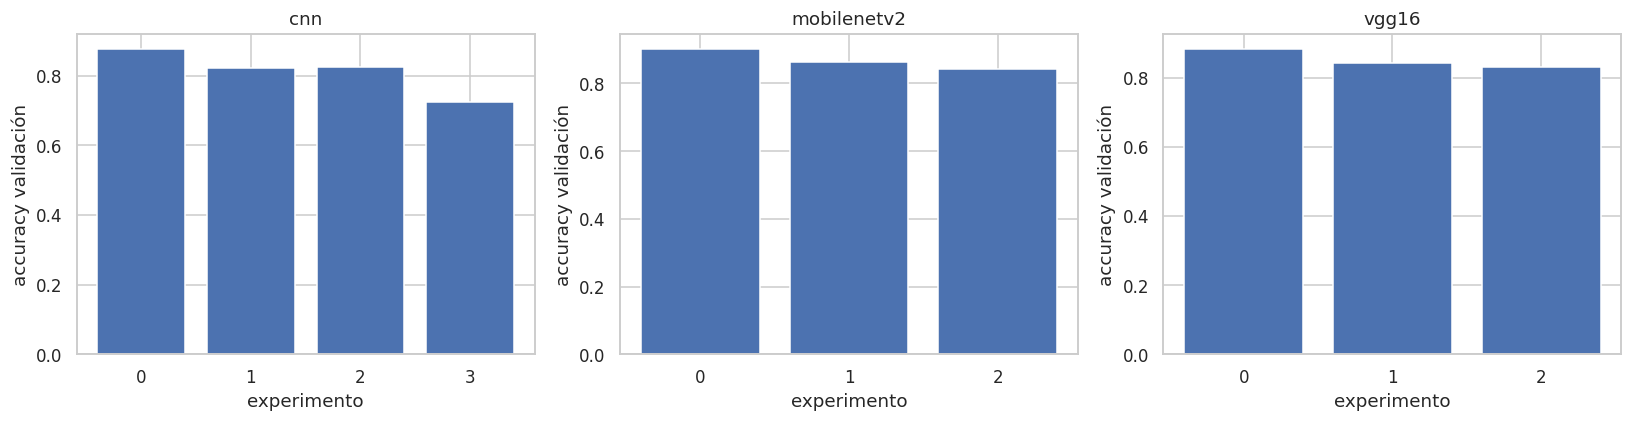

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (f, g) in zip(ax, search.groupby("family")):
    g = g.sort_values("run")
    a.bar(g.run.astype(str), g.val_accuracy)
    a.set_title(f)
    a.set_xlabel("experimento")
    a.set_ylabel("accuracy validación")
plt.tight_layout()
plt.savefig(RUTA_RES / "busqueda.png", dpi=180, bbox_inches="tight")
plt.show()


## 4. Entrenamiento final y fine-tuning

In [9]:
best = {f: json.loads(search[search.family == f]
                      .sort_values(["val_accuracy", "val_loss"], ascending=[False, True])
                      .iloc[0].config) for f in spaces}
print(json.dumps(best, indent=2))

models, hist, times = {}, {}, []
for f, cfg in best.items():
    tf.keras.backend.clear_session()
    gc.collect()
    seed_all()
    m = build(f, cfg)
    compile_m(m, cfg["lr"])
    t = time.perf_counter()
    h = m.fit(DS["train"], validation_data=DS["val"], epochs=EPOCHS_FINAL,
              callbacks=cbs("final_" + f), verbose=2)
    models[f] = m
    hist[f] = dict(h.history)
    times.append({"family": f, "stage": "base", "seconds": time.perf_counter() - t})

# Fine-tuning solo para las dos preentrenadas: se descongelan las últimas capas del backbone
# con un learning rate diez veces menor. La CNN desde cero no tiene esta fase, y eso hay que
# decirlo en el informe al comparar tiempos.
for f, n in {"vgg16": 4, "mobilenetv2": 20}.items():
    m = models[f]
    base = backbone_de(m)
    base.trainable = True
    for capa in base.layers[:-n]:
        capa.trainable = False
    for capa in base.layers:
        if isinstance(capa, tf.keras.layers.BatchNormalization):
            capa.trainable = False
    compile_m(m, best[f]["lr"] / 10)
    t = time.perf_counter()
    h = m.fit(DS["train"], validation_data=DS["val"], epochs=EPOCHS_FT,
              callbacks=cbs("finetune_" + f), verbose=2)
    for k, v in h.history.items():
        hist[f].setdefault(k, []).extend(v)
    times.append({"family": f, "stage": f"fine_tune_{n}", "seconds": time.perf_counter() - t})

# Al repositorio solo va el modelo de la CNN desde cero (unos 150 KB). VGG16 pesa ~56 MB y
# MobileNetV2 ~9 MB: quedan en RUTA_TMP por si hay que descargarlos.
models["cnn"].save(RUTA_RES / "modelo_cnn_desde_cero.keras")
for f in ("vgg16", "mobilenetv2"):
    models[f].save(RUTA_TMP / f"modelo_{f}.keras")

pd.DataFrame(times).to_csv(RUTA_RES / "tiempos.csv", index=False)
with open(RUTA_RES / "historias_final.json", "w", encoding="utf-8") as fh:
    json.dump(hist, fh)
print("\nmodelos guardados y tiempos escritos en", RUTA_RES)


{
  "cnn": {
    "filters": [
      32,
      64
    ],
    "drop": 0.0,
    "aug": false,
    "lr": 0.001
  },
  "vgg16": {
    "drop": 0.2,
    "aug": false,
    "lr": 0.001
  },
  "mobilenetv2": {
    "drop": 0.2,
    "aug": false,
    "lr": 0.001
  }
}
Epoch 1/30
422/422 - 8s - 20ms/step - accuracy: 0.6739 - loss: 0.9747 - val_accuracy: 0.7210 - val_loss: 0.7818 - learning_rate: 0.0010
Epoch 2/30
422/422 - 2s - 6ms/step - accuracy: 0.7909 - loss: 0.5950 - val_accuracy: 0.8203 - val_loss: 0.5301 - learning_rate: 0.0010
Epoch 3/30
422/422 - 2s - 5ms/step - accuracy: 0.8212 - loss: 0.5094 - val_accuracy: 0.7768 - val_loss: 0.5947 - learning_rate: 0.0010
Epoch 4/30
422/422 - 3s - 6ms/step - accuracy: 0.8376 - loss: 0.4601 - val_accuracy: 0.8210 - val_loss: 0.4924 - learning_rate: 0.0010
Epoch 5/30
422/422 - 2s - 6ms/step - accuracy: 0.8488 - loss: 0.4288 - val_accuracy: 0.7725 - val_loss: 0.6376 - learning_rate: 0.0010
Epoch 6/30
422/422 - 2s - 6ms/step - accuracy: 0.8578 - loss: 0.402

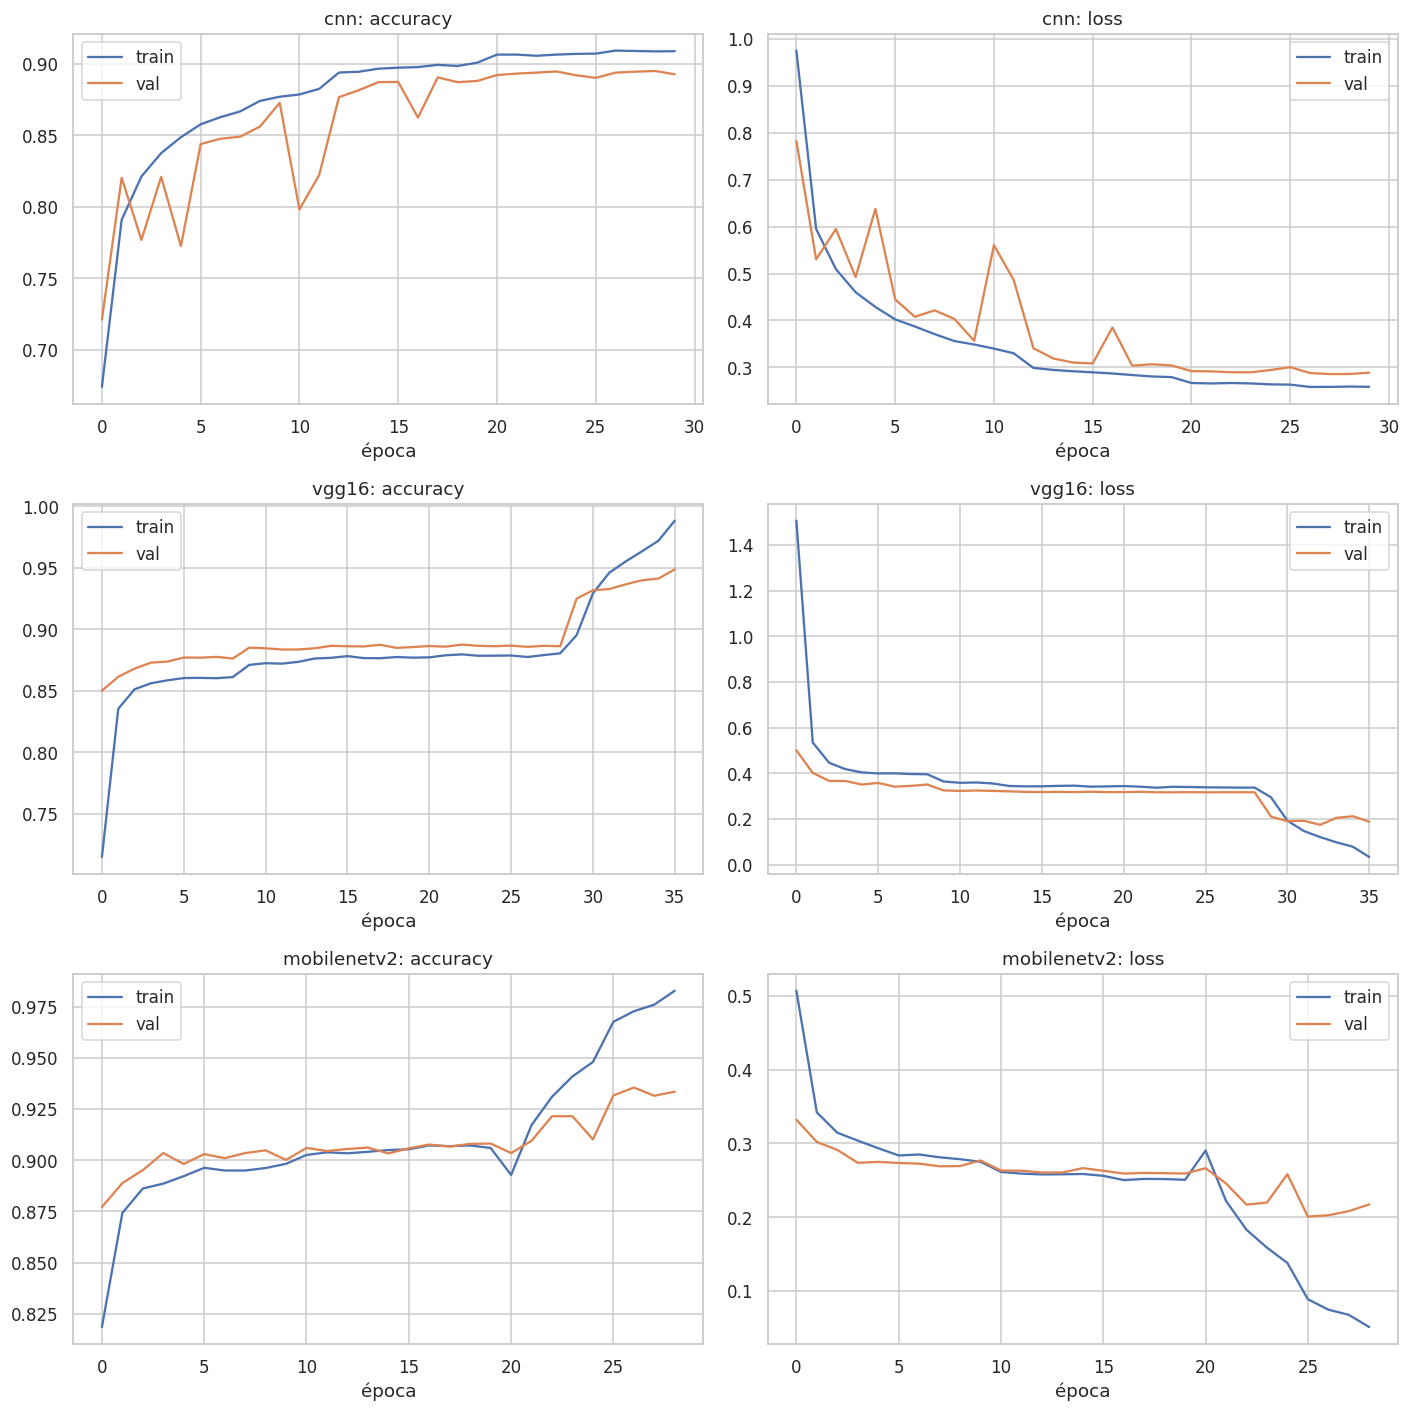

In [10]:
fig, ax = plt.subplots(3, 2, figsize=(13, 13))
for r, f in enumerate(["cnn", "vgg16", "mobilenetv2"]):
    for col, metric in enumerate(["accuracy", "loss"]):
        ax[r, col].plot(hist[f][metric], label="train")
        ax[r, col].plot(hist[f]["val_" + metric], label="val")
        ax[r, col].set_title(f"{f}: {metric}")
        ax[r, col].set_xlabel("época")
        ax[r, col].legend()
plt.tight_layout()
plt.savefig(RUTA_RES / "curvas.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Evaluación final, usada una sola vez sobre test

,Modelo,Accuracy,LogLoss,Precision_macro,Recall_macro,F1_macro,Parametros,Entrenables
1,vgg16,0.9319,0.192505,0.932685,0.9319,0.931924,14719818,7084554
2,mobilenetv2,0.9243,0.230052,0.924793,0.9243,0.924399,2270794,1207690
0,cnn,0.8904,0.309533,0.890618,0.8904,0.890365,28714,28522


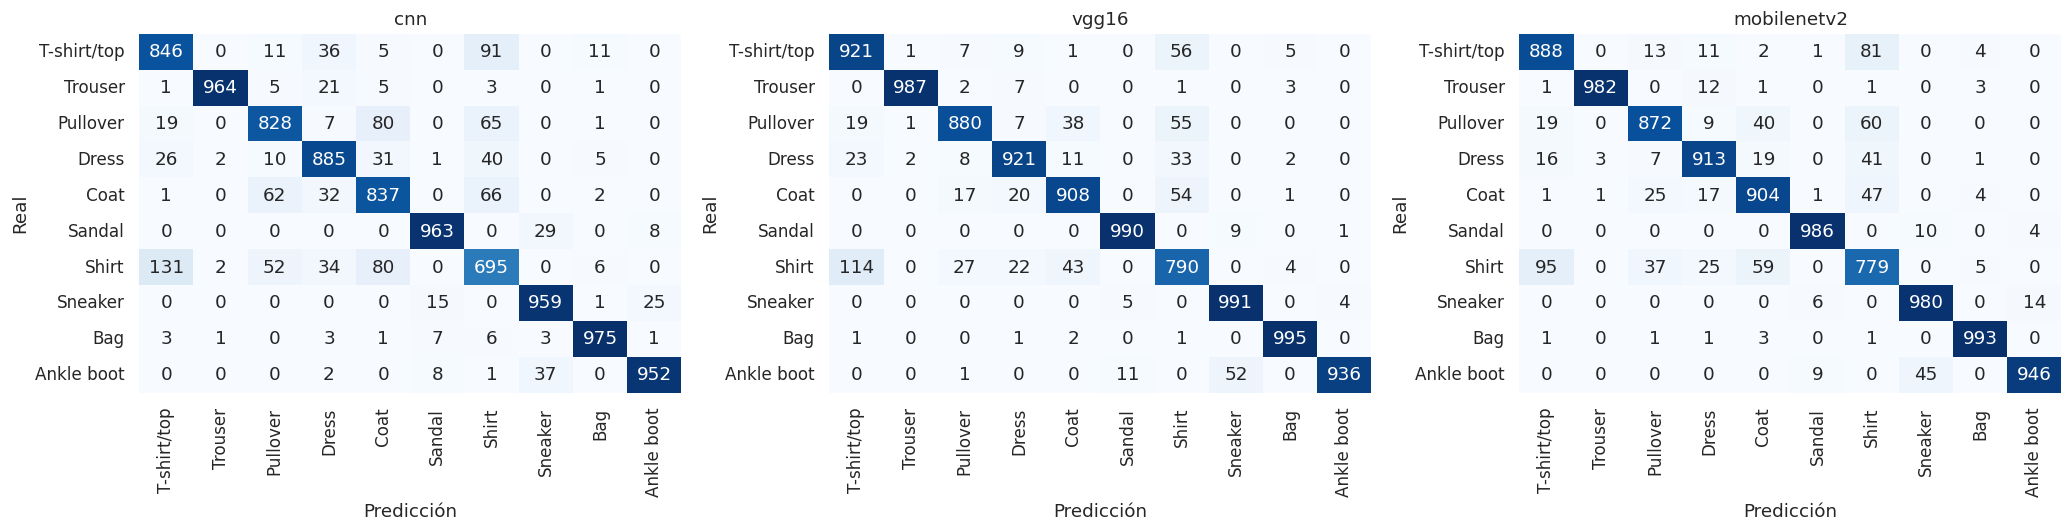

cnn


,precision,recall,f1-score,support
T-shirt/top,0.823759,0.8460,0.834731,1000.0000
Trouser,0.994840,0.9640,0.979177,1000.0000
Pullover,0.855372,0.8280,0.841463,1000.0000
Dress,0.867647,0.8850,0.876238,1000.0000
Coat,0.805582,0.8370,0.820991,1000.0000
Sandal,0.968813,0.9630,0.965898,1000.0000
Shirt,0.718718,0.6950,0.706660,1000.0000
Sneaker,0.932879,0.9590,0.945759,1000.0000
Bag,0.973054,0.9750,0.974026,1000.0000
Ankle boot,0.965517,0.9520,0.958711,1000.0000


vgg16


,precision,recall,f1-score,support
T-shirt/top,0.854360,0.9210,0.886429,1000.0000
Trouser,0.995964,0.9870,0.991462,1000.0000
Pullover,0.934183,0.8800,0.906282,1000.0000
Dress,0.933131,0.9210,0.927026,1000.0000
Coat,0.905284,0.9080,0.906640,1000.0000
Sandal,0.984095,0.9900,0.987039,1000.0000
Shirt,0.797980,0.7900,0.793970,1000.0000
Sneaker,0.942015,0.9910,0.965887,1000.0000
Bag,0.985149,0.9950,0.990050,1000.0000
Ankle boot,0.994687,0.9360,0.964451,1000.0000


mobilenetv2


,precision,recall,f1-score,support
T-shirt/top,0.869736,0.8880,0.878773,1000.0000
Trouser,0.995943,0.9820,0.988922,1000.0000
Pullover,0.913089,0.8720,0.892072,1000.0000
Dress,0.924089,0.9130,0.918511,1000.0000
Coat,0.879377,0.9040,0.891519,1000.0000
Sandal,0.983051,0.9860,0.984523,1000.0000
Shirt,0.771287,0.7790,0.775124,1000.0000
Sneaker,0.946860,0.9800,0.963145,1000.0000
Bag,0.983168,0.9930,0.988060,1000.0000
Ankle boot,0.981328,0.9460,0.963340,1000.0000


In [11]:
metrics, preds, probs = [], {}, {}
for f, m in models.items():
    pr = m.predict(DS["test"], verbose=0)
    yp = pr.argmax(1)
    preds[f], probs[f] = yp, pr
    p, r, f1, _ = precision_recall_fscore_support(y_test, yp, average="macro", zero_division=0)
    metrics.append({
        "Modelo": f,
        "Accuracy": accuracy_score(y_test, yp),
        "LogLoss": log_loss(y_test, pr, labels=list(range(NUM_CLASSES))),
        "Precision_macro": p,
        "Recall_macro": r,
        "F1_macro": f1,
        "Parametros": int(m.count_params()),
        "Entrenables": int(sum(np.prod(v.shape) for v in m.trainable_weights)),
    })

met = pd.DataFrame(metrics).sort_values("F1_macro", ascending=False)
met.to_csv(RUTA_RES / "metricas_test.csv", index=False)
display(met)

fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for a, f in zip(ax, ["cnn", "vgg16", "mobilenetv2"]):
    sns.heatmap(confusion_matrix(y_test, preds[f]), annot=True, fmt="d", cmap="Blues",
                cbar=False, ax=a, xticklabels=classes, yticklabels=classes)
    a.set_title(f)
    a.set_xlabel("Predicción")
    a.set_ylabel("Real")
    a.tick_params(axis="x", rotation=90)
    a.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(RUTA_RES / "confusion.png", dpi=180, bbox_inches="tight")
plt.show()

for f in models:
    reporte = pd.DataFrame(classification_report(
        y_test, preds[f], target_names=classes, output_dict=True)).T
    reporte.to_csv(RUTA_RES / f"reporte_{f}.csv")
    print(f)
    display(reporte)


## 6. Análisis de errores e incertidumbre


cnn
Shirt -> T-shirt/top: 131
T-shirt/top -> Shirt: 91
Shirt -> Coat: 80
Pullover -> Coat: 80
Coat -> Shirt: 66

vgg16
Shirt -> T-shirt/top: 114
T-shirt/top -> Shirt: 56
Pullover -> Shirt: 55
Coat -> Shirt: 54
Ankle boot -> Sneaker: 52

mobilenetv2
Shirt -> T-shirt/top: 95
T-shirt/top -> Shirt: 81
Pullover -> Shirt: 60
Shirt -> Coat: 59
Coat -> Shirt: 47


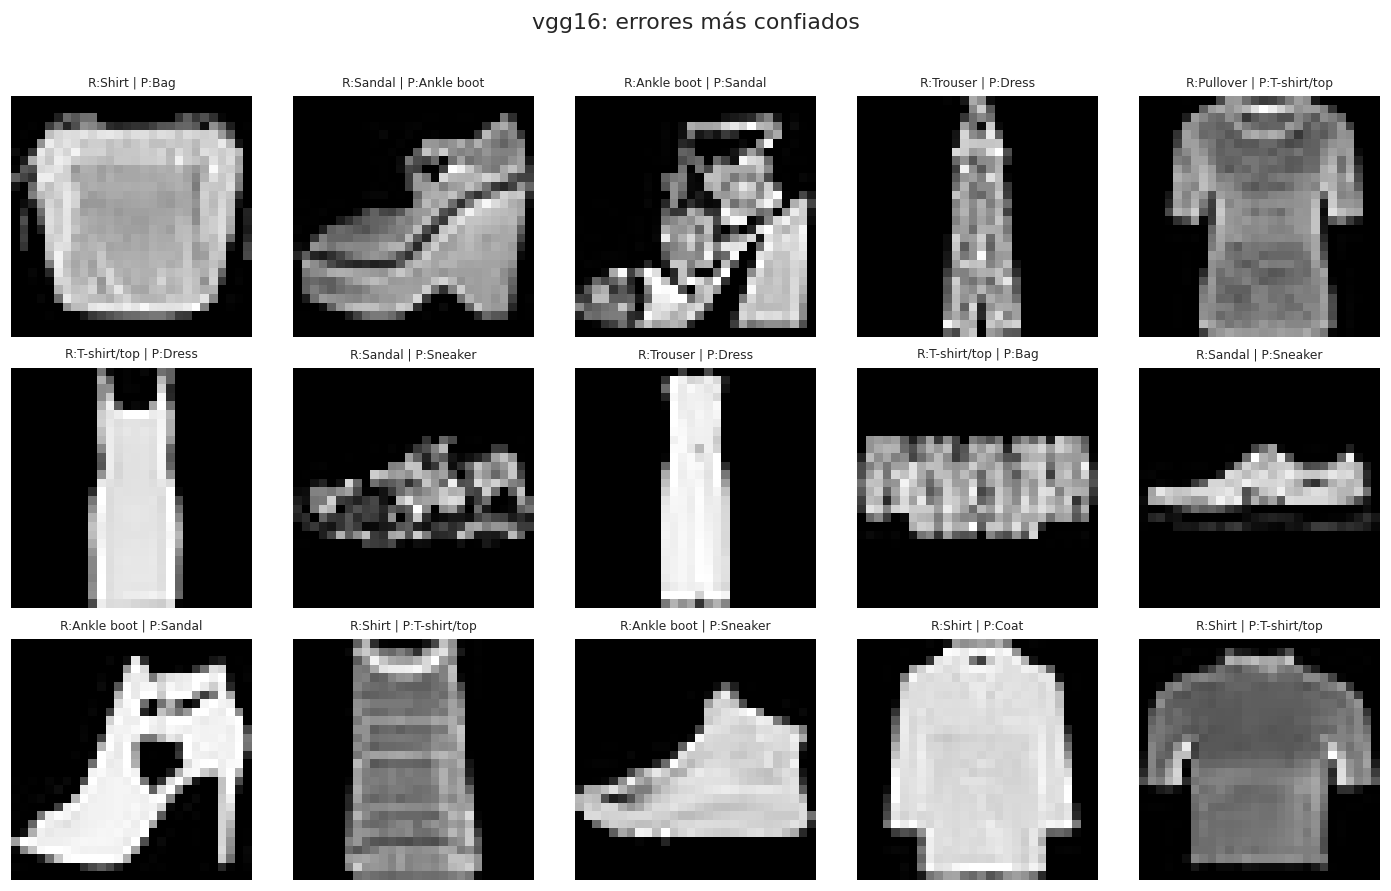

,Modelo,Accuracy,IC95_inf,IC95_sup
0,cnn,0.8904,0.884600,0.896303
1,vgg16,0.9319,0.926900,0.936702
2,mobilenetv2,0.9243,0.918998,0.929503


In [12]:
for f in models:
    cm = confusion_matrix(y_test, preds[f])
    np.fill_diagonal(cm, 0)
    pares = np.dstack(np.unravel_index(np.argsort(cm.ravel())[::-1][:5], cm.shape))[0]
    print()
    print(f)
    for i, j in pares:
        print(f"{classes[i]} -> {classes[j]}: {cm[i, j]}")

best_f = met.iloc[0].Modelo
err = np.where(preds[best_f] != y_test)[0]
err = err[np.argsort(probs[best_f][err, preds[best_f][err]])[::-1][:15]]
fig, ax = plt.subplots(3, 5, figsize=(13, 8))
for i, a in zip(err, ax.flat):
    a.imshow(x_test[i], cmap="gray")
    a.set_title(f"R:{classes[y_test[i]]} | P:{classes[preds[best_f][i]]}", fontsize=8)
    a.axis("off")
fig.suptitle(f"{best_f}: errores más confiados", y=1.01)
plt.tight_layout()
plt.savefig(RUTA_RES / "errores.png", dpi=180, bbox_inches="tight")
plt.show()

# Intervalo de confianza del accuracy por bootstrap sobre el conjunto de test.
rng = np.random.default_rng(SEED)
B = N_BOOTSTRAP
boot = []
for f in models:
    correcto = (preds[f] == y_test).astype(float)
    muestras = [correcto[rng.integers(0, len(y_test), len(y_test))].mean() for _ in range(B)]
    boot.append({"Modelo": f, "Accuracy": correcto.mean(),
                 "IC95_inf": np.percentile(muestras, 2.5),
                 "IC95_sup": np.percentile(muestras, 97.5)})
boot = pd.DataFrame(boot)
boot.to_csv(RUTA_RES / "bootstrap.csv", index=False)
display(boot)


## 7. Observaciones

Corrida con `PRESUPUESTO = "completo"` en una Tesla T4, en float32 (ver `entorno.json`).

**Búsqueda (sección 3).** En las tres familias ganó la misma receta: sin aumentación y con `lr = 1e-3`
(CNN 87.65 %, VGG16 88.30 % y MobileNetV2 90.13 % en validación). Las corridas con aumentación quedaron
entre 3.9 y 5.5 puntos por debajo, aunque también tenían más dropout, así que el efecto no se puede atribuir
solo a la aumentación. Con `lr = 1e-4` las tres quedaron subentrenadas: las curvas seguían subiendo al final
de las 12 épocas. Duplicar los filtros de la CNN (64–128) apenas cambió la validación (82.53 % frente a
82.12 %, ambas con aumentación) y triplicó los parámetros. La brecha entrenamiento − validación es negativa
en casi todas las corridas porque el accuracy de entrenamiento se mide con dropout y aumentación activos:
ninguna configuración sobreajustaba en 12 épocas, y por eso la regularización extra solo estorbó.

**Entrenamiento final (sección 4).** La CNN usó las 30 épocas y su mejor época fue la 28 (89.47 % en
validación). VGG16 con el backbone congelado se estancó en 88.67 %, por debajo de la CNN propia, y el
fine-tuning del último bloque la llevó a 93.65 %. MobileNetV2 arrancó mejor congelada (90.77 %) y el
fine-tuning la subió a 93.17 %. Las características de ImageNet no sirven tal cual para prendas pequeñas en
gris: hay que adaptar al menos el último bloque. La CNN no tiene fase de fine-tuning, así que las
preentrenadas recibieron más épocas en total.

**Test (sección 5).** VGG16 93.19 % (IC 95 % 92.69–93.67), MobileNetV2 92.43 % (91.90–92.95) y CNN
89.04 % (88.46–89.63), con el mismo orden en F1 macro y log-loss. Los intervalos separan con claridad a la
CNN de las preentrenadas; los de VGG16 y MobileNetV2 se solapan, pero la comparación pareada del notebook
`03` (bootstrap pareado y McNemar sobre las mismas imágenes) muestra que la diferencia de 0.76 puntos sí es
significativa (p = 0.0015), aunque pequeña.

**Errores (sección 6).** Las tres redes fallan en lo mismo: *Shirt* es la clase más difícil (F1 de 0.71 en
la CNN, 0.78 en MobileNetV2 y 0.79 en VGG16) y el par más confundido es camisa con camiseta, entre 95 y 131
casos según el modelo, seguido de pullover, abrigo y camisa. Varios de los errores más confiados de VGG16
parecen errores de etiqueta del conjunto de datos, no del modelo.

**Ventajas y desventajas.**
- **CNN desde cero:** trabaja en la resolución nativa, tiene 28,714 parámetros y entrena en 79 s; es la de
  menor accuracy y la que peor distingue las prendas superiores.
- **VGG16:** el mejor accuracy y el menor log-loss, pero 14.7 M de parámetros y 2,687 s de GPU; congelada
  rinde menos que la CNN propia.
- **MobileNetV2:** 0.76 puntos por debajo de VGG16 con 6.5 veces menos parámetros y 8 veces menos tiempo
  (340 s); es la opción más equilibrada entre estas tres cuando el costo importa.

In [13]:
resumen = (met
           .merge(pd.DataFrame(times).groupby("family", as_index=False).seconds.sum(),
                  left_on="Modelo", right_on="family")
           .drop(columns="family")
           .merge(boot[["Modelo", "IC95_inf", "IC95_sup"]], on="Modelo"))
resumen.to_csv(RUTA_RES / "resumen_final.csv", index=False)
display(resumen)

entorno = {
    "tensorflow": tf.__version__,
    "gpu": tf.config.list_physical_devices("GPU")[0].name if HAY_GPU else None,
    "presupuesto": PRESUPUESTO,
    "precision": tf.keras.mixed_precision.global_policy().name,
    "seed": SEED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "imagenes_busqueda": N_BUSQUEDA or 54000,
    "epochs_search": EPOCHS_SEARCH,
    "epochs_final": EPOCHS_FINAL,
    "epochs_fine_tuning": EPOCHS_FT,
    "mejores_config": best,
    "duplicados_desarrollo": int(repetidas_dev),
    "imagenes_test_repetidas_en_desarrollo": int(fuga_test),
}
with open(RUTA_RES / "entorno.json", "w", encoding="utf-8") as fh:
    json.dump(entorno, fh, indent=2, ensure_ascii=False)

print("archivos generados en results/punto2/:")
for p in sorted(RUTA_RES.iterdir()):
    if p.is_file():
        print(f"  {p.name:<34} {p.stat().st_size / 1024:8.1f} KB")

print("\nPara dejar esto en el repo desde Colab:")
print("  1. Archivo > Guardar una copia en GitHub (rama punto2), para subir el notebook corrido.")
print("  2. Hacer commit de results/punto2/ desde una celda con git, o descargar la carpeta")
print("     y commitearla en local.")


,Modelo,Accuracy,LogLoss,Precision_macro,Recall_macro,F1_macro,Parametros,Entrenables,seconds,IC95_inf,IC95_sup
0,vgg16,0.9319,0.192505,0.932685,0.9319,0.931924,14719818,7084554,2687.005973,0.926900,0.936702
1,mobilenetv2,0.9243,0.230052,0.924793,0.9243,0.924399,2270794,1207690,339.945875,0.918998,0.929503
2,cnn,0.8904,0.309533,0.890618,0.8904,0.890365,28714,28522,78.706619,0.884600,0.896303


archivos generados en results/punto2/:
  .gitkeep                                0.0 KB
  bootstrap.csv                           0.1 KB
  busqueda.png                           49.4 KB
  confusion.png                         217.4 KB
  curvas.png                            320.6 KB
  ejemplos_clases.png                    48.0 KB
  entorno.json                            0.7 KB
  errores.png                            90.6 KB
  experimentos.csv                        1.8 KB
  historias_busqueda.json                12.9 KB
  historias_final.json                    9.9 KB
  metricas_test.csv                       0.4 KB
  modelo_cnn_desde_cero.keras           394.8 KB
  reporte_cnn.csv                         0.8 KB
  reporte_mobilenetv2.csv                 0.8 KB
  reporte_vgg16.csv                       0.8 KB
  resumen_final.csv                       0.5 KB
  tiempos.csv                             0.2 KB

Para dejar esto en el repo desde Colab:
  1. Archivo > Guardar una copia en Gi

In [14]:
np.savez_compressed(
    RUTA_RES / "predicciones_test.npz",
    y_test=y_test,
    **{f"probs_{f}": probs[f] for f in models},
)
print("guardado:", (RUTA_RES / "predicciones_test.npz").stat().st_size // 1024, "KB")

guardado: 1131 KB


## Referencias

[1] H. Xiao, K. Rasul, and R. Vollgraf, “Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms,” arXiv:1708.07747, 2017.  
[2] K. Simonyan and A. Zisserman, “Very Deep Convolutional Networks for Large-Scale Image Recognition,” ICLR, 2015.  
[3] M. Sandler et al., “MobileNetV2: Inverted Residuals and Linear Bottlenecks,” CVPR, 2018.  
[4] TensorFlow, “Transfer learning and fine-tuning,” documentación oficial.
